# Coronary Stenosis Model Training with Random Downsampling

**Pipeline:**
- Same train/test split as data exploration (patient-level)
- Random downsampling healthy → same N as stenosis (1:1)
- All 2191 features (no RF top-50 selection here)
- Models: Logistic Regression (baseline) + Random Forest + XGBoost + SVM
- Metric: Average Precision

## 0. Imports & config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix, accuracy_score, f1_score, classification_report,
    roc_auc_score, precision_score, recall_score, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from sklearn.svm import SVC
from scipy.stats import loguniform, uniform
from scipy.ndimage import uniform_filter1d

RANDOM_STATE = 42
TARGET_COL   = 'label'

## 1. Load

In [2]:
# Nº de features
N_FEAT = 50
feat_cols  = [f'feat{i}' for i in range(1, N_FEAT + 1)] 
all_cols   = feat_cols + ['label']                       

# Test pos/neg: SIN header → lo inyectamos nosotros
train_pos = pd.read_csv('C:/Users/mluser/IPA_ML/notebooks/notebooks/csv_files/oriented_rois/ucasML/train_positive.csv',
                       header=None, names=feat_cols)
train_pos['label'] = 1

train_neg = pd.read_csv('C:/Users/mluser/IPA_ML/notebooks/notebooks/csv_files/oriented_rois/ucasML/train_negative.csv',
                       header=None, names=feat_cols)
train_neg['label'] = 0

# Merge test 
train = pd.concat([train_pos, train_neg], ignore_index=True)
print(f"  pos: {(train['label']==1).sum()}  neg: {(train['label']==0).sum()}")
print(f"train shape: {train.shape}")          # (4215, 51)

# Test pos/neg
test_pos = pd.read_csv('C:/Users/mluser/IPA_ML/notebooks/notebooks/csv_files/oriented_rois/ucasML/test_positive.csv',
                       header=None, names=feat_cols)
test_pos['label'] = 1

test_neg = pd.read_csv('C:/Users/mluser/IPA_ML/notebooks/notebooks/csv_files/oriented_rois/ucasML/test_negative.csv',
                       header=None, names=feat_cols)
test_neg['label'] = 0

# Merge test
test = pd.concat([test_pos, test_neg], ignore_index=True)
print(f"test shape:  {test.shape}")           # (18198, 51)
print(f"  pos: {(test['label']==1).sum()}  neg: {(test['label']==0).sum()}")

#  Final splits
X_train_scaled = train[feat_cols].values
y_train = train['label'].values

X_test_scaled  = test[feat_cols].values
y_test  = test['label'].values

  pos: 2108  neg: 29367
train shape: (31475, 51)
test shape:  (11200, 51)
  pos: 455  neg: 10745


In [3]:
# Class separation
train_pos = train[train['label'] == 1]
train_neg = train[train['label'] == 0]

n_pos = len(train_pos)

# Random downsampling of the negative class
train_neg_down = train_neg.sample(
    n=n_pos,
    random_state=RANDOM_STATE
)

# Balanced dataset 1:1
train_balanced = pd.concat([train_pos, train_neg_down]) \
                   .sample(frac=1, random_state=RANDOM_STATE) \
                   .reset_index(drop=True)

print(f"Before  - Pos: {len(train_pos)}  Neg: {len(train_neg)}")
print(f"After - Pos: {len(train_pos)}  Neg: {len(train_neg_down)}")

X_train_scaled = train_balanced[feat_cols].values
y_train = train_balanced['label'].values

X_test_scaled = test[feat_cols].values
y_test = test['label'].values

Before  - Pos: 2108  Neg: 29367
After - Pos: 2108  Neg: 2108


## 2. Helpers

In [4]:
results = {}

def print_metrics(name, y_true, y_pred, y_prob=None):
    """Printed metrics of binary classification"""
    print(f'  {name}')
    print(f'  Accuracy    : {accuracy_score(y_true, y_pred):.4f}')
    print(f'  Precision   : {precision_score(y_true, y_pred):.4f}')
    print(f'  Sensitivity : {recall_score(y_true, y_pred):.4f}')  # = Recall
    print(f'  Specificity : {recall_score(y_true, y_pred, pos_label=0):.4f}')
    print(f'  F1-score    : {f1_score(y_true, y_pred):.4f}')
    if y_prob is not None:
        print(f'  ROC-AUC     : {roc_auc_score(y_true, y_prob):.4f}')
    print()
    print(classification_report(y_true, y_pred,
                                target_names=['Healthy', 'Stenosis']))

# Fixed Confusion Matrix 
def plot_confusion_matrix(name, y_true, y_pred):
    """Plot confusion matrix — grid lines suppressed."""
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        display_labels=['Healthy', 'Stenosis'],
        cmap='Blues',
        ax=ax,
        colorbar=True
    )
    ax.grid(False)
    ax.set_title(f'{name} — Confusion Matrix', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Fit, predict and print full metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    f1  = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    p   = precision_score(y_te, y_pred)
    r   = recall_score(y_te, y_pred)

    print(f'\n{"═"*55}')
    print(f'  {name}')
    print(f'{"─"*55}')
    print(f'  F1        : {f1:.4f}')
    print(f'  Precision : {p:.4f}')
    print(f'  Recall    : {r:.4f}')
    print(f'  ROC-AUC   : {auc:.4f}')
    print(f'{"─"*55}')
    print(classification_report(y_te, y_pred, target_names=['Healthy', 'Stenosis']))

    plot_confusion_matrix(name, y_te, y_pred)

    return {'model': model, 'f1': f1, 'auc': auc, 'precision': p, 'recall': r}


def plot_froc(name, y_true, y_prob, n_images=None):
    """
    FROC curve: sensitivity vs average False Positives per image.
    """
    thresholds = np.linspace(0, 1, 200)
    sensitivities = []
    fp_per_image  = []

    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        cm       = confusion_matrix(y_true, y_pred_t)
        tn, fp, fn, tp = cm.ravel()

        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpi  = fp / n_images if n_images else fp

        sensitivities.append(sens)
        fp_per_image.append(fpi)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(fp_per_image, sensitivities, color='#E85D24', lw=2)
    ax.set_xlabel('False Positives per image' if n_images else 'Total False Positives')
    ax.set_ylabel('Sensitivity (TPR)')
    ax.set_title(f'{name} — FROC Curve')
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

def plot_froc_smooth(name, y_true, y_prob, n_images=None):
    thresholds    = np.linspace(0, 1, 500)
    sensitivities = []
    fp_per_image  = []

    for t in thresholds:
        y_pred_t     = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpi  = fp / n_images if n_images else fp
        sensitivities.append(sens)
        fp_per_image.append(fpi)

    # Suavizar
    sens_smooth = uniform_filter1d(sensitivities, size=15)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(fp_per_image, sensitivities, color='#AACCE4', lw=1,
            alpha=0.5, label='Raw')
    ax.plot(fp_per_image, sens_smooth, color='#E85D24', lw=2.5,
            label='Smoothed')
    ax.set_xlabel('Average False Positives per image')
    ax.set_ylabel('Sensitivity (TPR)')
    ax.set_title(f'{name} — FROC Curve')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

In [5]:
test_meta = pd.read_csv('test_top50_features_ORIENTED.csv', usecols=['frame_id'])
n_images = test_meta['frame_id'].nunique()
print(f'Images in test: {n_images}')

Images in test: 66


## 3. Baseline — Logistic Regression


═══════════════════════════════════════════════════════
  Logistic Regression (baseline)
───────────────────────────────────────────────────────
  F1        : 0.1188
  Precision : 0.0657
  Recall    : 0.6176
  ROC-AUC   : 0.6562
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

     Healthy       0.97      0.63      0.76     10745
    Stenosis       0.07      0.62      0.12       455

    accuracy                           0.63     11200
   macro avg       0.52      0.62      0.44     11200
weighted avg       0.94      0.63      0.74     11200



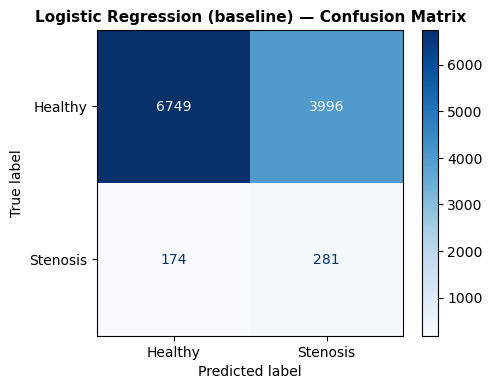

In [8]:
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='saga',     
    n_jobs=18,
    random_state=RANDOM_STATE
)

results['LR'] = evaluate_model(
    'Logistic Regression (baseline)',
    lr,
    X_train_scaled, y_train,
    X_test_scaled,  y_test
)

In [9]:
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print_metrics('Linear Regression', y_test, y_pred_lr, y_prob_lr)


  Linear Regression
  Accuracy    : 0.6277
  Precision   : 0.0657
  Sensitivity : 0.6176
  Specificity : 0.6281
  F1-score    : 0.1188
  ROC-AUC     : 0.6562

              precision    recall  f1-score   support

     Healthy       0.97      0.63      0.76     10745
    Stenosis       0.07      0.62      0.12       455

    accuracy                           0.63     11200
   macro avg       0.52      0.62      0.44     11200
weighted avg       0.94      0.63      0.74     11200



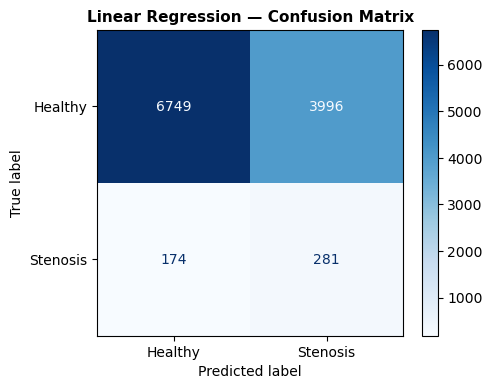

In [21]:
plot_confusion_matrix('Linear Regression', y_test, y_pred_lr)


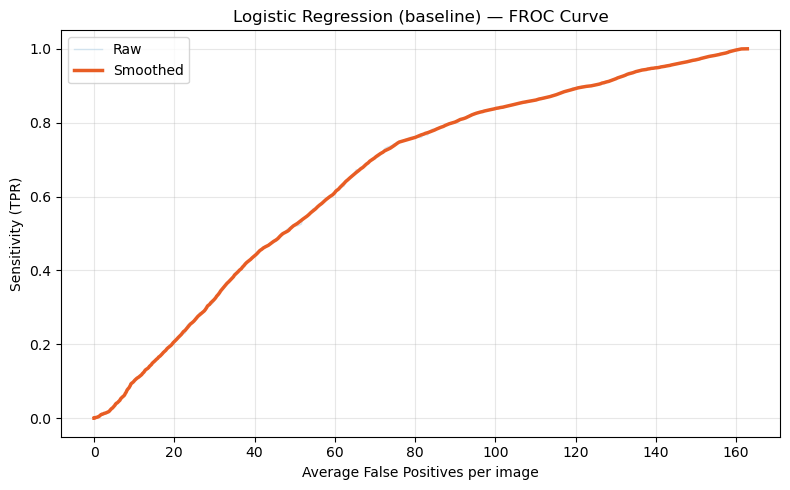

In [22]:
y_prob_lr = results['LR']['model'].predict_proba(X_test_scaled)[:, 1]

plot_froc_smooth('Logistic Regression (baseline)', y_test, y_prob_lr, n_images=n_images)

In [23]:
with open('lr_model_random.pkl', 'wb') as file: #--> If you see errors here, try changing the directory to /ML/Models
    pickle.dump(lr, file)

## 4. Random Forest — GridSearchCV

In [28]:
param_grid_rf = {
    'n_estimators'     : [200, 500],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.3],
    'class_weight'     : ['balanced', 'balanced_subsample', None],
}

rf_base = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=24
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_rf = GridSearchCV(
    rf_base,
    param_grid_rf,
    scoring='average_precision',
    cv=cv,
    n_jobs=24,
    verbose=2,
    refit=True
)

print('Launching GridSearchCV RF — this may take 30-60 min...')
grid_rf.fit(X_train_scaled, y_train)
print(f'\nBest params : {grid_rf.best_params_}')
print(f'Best CV F1  : {grid_rf.best_score_:.4f}')

best_rf = grid_rf.best_estimator_

Launching GridSearchCV RF — this may take 30-60 min...
Fitting 5 folds for each of 648 candidates, totalling 3240 fits

Best params : {'class_weight': 'balanced', 'max_depth': 30, 'max_features': 0.3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best CV F1  : 0.8401



═══════════════════════════════════════════════════════
  Random Forest (GridSearchCV)
───────────────────────────────────────────────────────
  F1        : 0.1205
  Precision : 0.0683
  Recall    : 0.5121
  ROC-AUC   : 0.6762
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

     Healthy       0.97      0.70      0.82     10745
    Stenosis       0.07      0.51      0.12       455

    accuracy                           0.70     11200
   macro avg       0.52      0.61      0.47     11200
weighted avg       0.93      0.70      0.79     11200



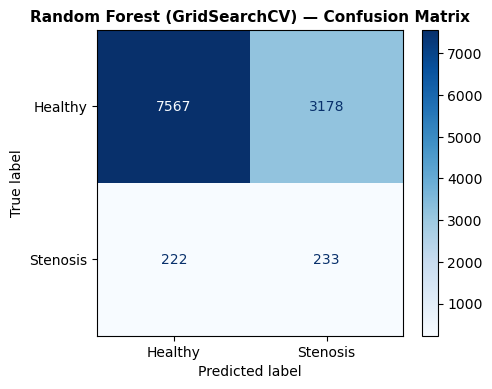

In [30]:
results['RF'] = evaluate_model(
    'Random Forest (GridSearchCV)',
    best_rf,
    X_train_scaled, y_train,
    X_test_scaled,  y_test
)

In [31]:
y_pred_rf = best_rf.predict(X_test_scaled)
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

print_metrics('Random Forest', y_test, y_pred_rf, y_prob_rf)


  Random Forest
  Accuracy    : 0.6964
  Precision   : 0.0683
  Sensitivity : 0.5121
  Specificity : 0.7042
  F1-score    : 0.1205
  ROC-AUC     : 0.6762

              precision    recall  f1-score   support

     Healthy       0.97      0.70      0.82     10745
    Stenosis       0.07      0.51      0.12       455

    accuracy                           0.70     11200
   macro avg       0.52      0.61      0.47     11200
weighted avg       0.93      0.70      0.79     11200



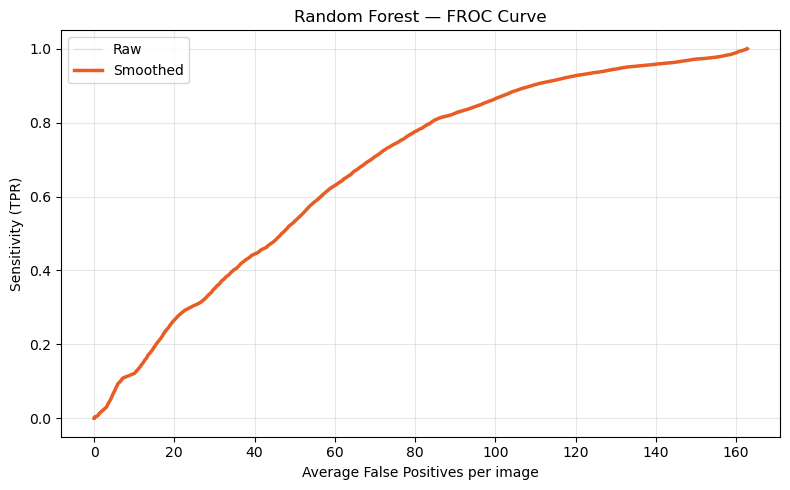

In [34]:
plot_froc_smooth('Random Forest', y_test, y_prob_rf, n_images=n_images)

In [35]:
with open('rf_model_random.pkl', 'wb') as file: #--> If you see errors here, try changing the directory to /ML/Models
    pickle.dump(best_rf, file)

## 5. XGBoost

In [36]:
param_grid_xgb = {
    'n_estimators'    : [300, 500, 700, 1000],
    'max_depth'       : [3, 4, 5, 6, 8],
    'learning_rate'   : [0.005, 0.01, 0.05, 0.1],
    'subsample'       : [0.6, 0.75, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.75, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'gamma'           : [0, 0.1, 0.2, 0.5, 1.0],
    'reg_alpha'       : [0, 0.01, 0.1, 1.0],
    'reg_lambda'      : [0.5, 1.0, 5.0, 10.0],
}

xgb_base = XGBClassifier(
    scale_pos_weight  = 1,
    objective         = 'binary:logistic',
    eval_metric       = 'aucpr',
    use_label_encoder = False,
    random_state      = RANDOM_STATE,
    tree_method       = 'hist',
    device            = 'cuda',
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search_xgb = RandomizedSearchCV(
    xgb_base, param_grid_xgb,
    n_iter          = 60,
    scoring         = 'average_precision',
    cv              = cv,
    n_jobs          = 1,     
    verbose         = 2,
    random_state    = RANDOM_STATE,
    refit           = True,
)

search_xgb.fit(X_train_scaled, y_train)

print(f'\nBest params : {search_xgb.best_params_}')
print(f'Best CV AP  : {search_xgb.best_score_:.4f}')

best_xgb = search_xgb.best_estimator_

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV] END colsample_bytree=0.75, gamma=0, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   1.6s
[CV] END colsample_bytree=0.75, gamma=0, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   1.5s
[CV] END colsample_bytree=0.75, gamma=0, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   1.5s
[CV] END colsample_bytree=0.75, gamma=0, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   1.5s
[CV] END colsample_bytree=0.75, gamma=0, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   1.5s
[CV] END colsample_bytree=0.75, gamma=0.2, learning_rate=0

In [38]:
y_prob_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]
y_pred_xgb = best_xgb.predict(X_test_scaled)

print_metrics('XGBoost (Tuned)', y_test, y_pred_xgb, y_prob=y_prob_xgb)


  XGBoost (Tuned)
  Accuracy    : 0.7197
  Precision   : 0.0745
  Sensitivity : 0.5165
  Specificity : 0.7283
  F1-score    : 0.1302
  ROC-AUC     : 0.6803

              precision    recall  f1-score   support

     Healthy       0.97      0.73      0.83     10745
    Stenosis       0.07      0.52      0.13       455

    accuracy                           0.72     11200
   macro avg       0.52      0.62      0.48     11200
weighted avg       0.94      0.72      0.80     11200



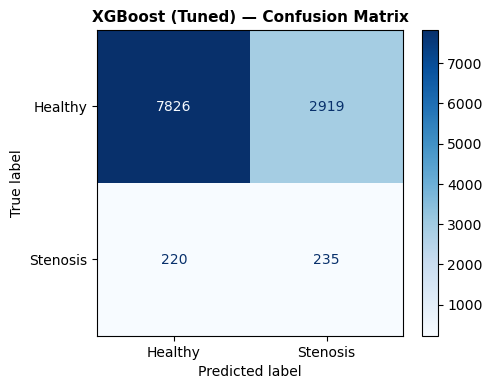

In [39]:
plot_confusion_matrix('XGBoost (Tuned)', y_test, y_pred_xgb)


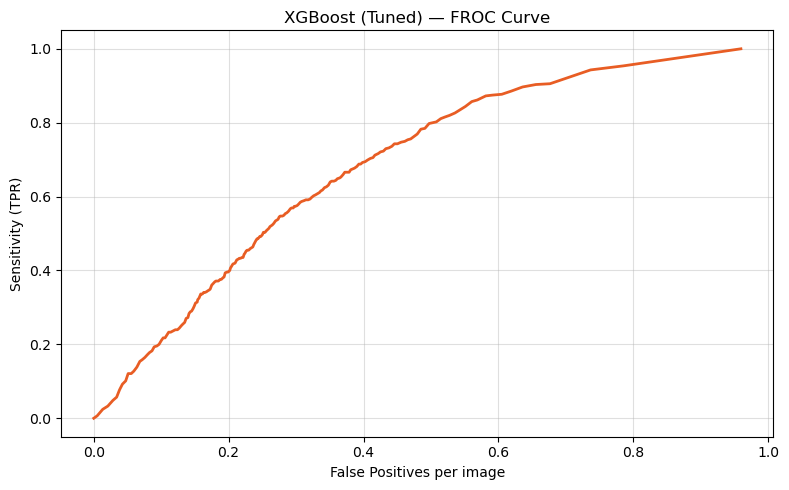

In [41]:
plot_froc('XGBoost (Tuned)', y_test, y_prob_xgb, n_images=len(y_test))

In [43]:
with open('xgb_model_random.pkl', 'wb') as file: #--> If you see errors here, try changing the directory to /ML/Models
    pickle.dump(best_xgb, file)

## 6. SVM

In [44]:
param_grid_svm = {
    'C'      : loguniform(1e-2, 1e3),      
    'gamma'  : loguniform(1e-4, 1e1),    
    'kernel' : ['rbf', 'poly', 'sigmoid'],
    'degree' : [2, 3, 4],             
    'class_weight': [None, 'balanced'],
}

svm_base = SVC(
    probability=True,        
    random_state=RANDOM_STATE,
    cache_size=2000,          
    max_iter=5000,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search_svm = RandomizedSearchCV(
    svm_base, param_grid_svm,
    n_iter=60,
    scoring='average_precision',
    cv=cv,
    n_jobs=-1,             
    verbose=2,
    random_state=RANDOM_STATE,
    refit=True,
)

search_svm.fit(X_train_scaled, y_train)

print(f'\nBest params : {search_svm.best_params_}')
print(f'Best CV AP  : {search_svm.best_score_:.4f}')
best_svm = search_svm.best_estimator_

Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best params : {'C': np.float64(30.124649092490525), 'class_weight': None, 'degree': 3, 'gamma': np.float64(8.144074102761957), 'kernel': 'rbf'}
Best CV AP  : 0.8572


In [45]:
y_prob_svm = best_svm.predict_proba(X_test_scaled)[:, 1]
y_pred_svm = best_svm.predict(X_test_scaled)

print_metrics('SVM', y_test, y_pred_svm, y_prob=y_prob_svm)


  SVM
  Accuracy    : 0.7288
  Precision   : 0.0742
  Sensitivity : 0.4945
  Specificity : 0.7388
  F1-score    : 0.1291
  ROC-AUC     : 0.6884

              precision    recall  f1-score   support

     Healthy       0.97      0.74      0.84     10745
    Stenosis       0.07      0.49      0.13       455

    accuracy                           0.73     11200
   macro avg       0.52      0.62      0.48     11200
weighted avg       0.94      0.73      0.81     11200



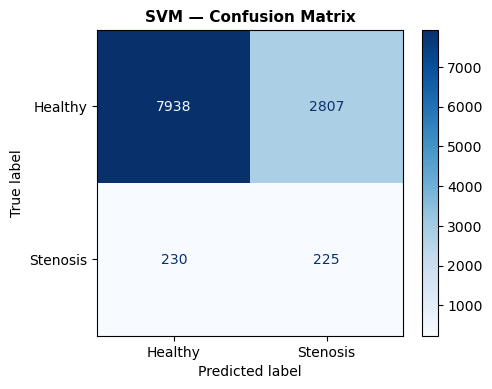

In [46]:
plot_confusion_matrix('SVM', y_test, y_pred_svm)


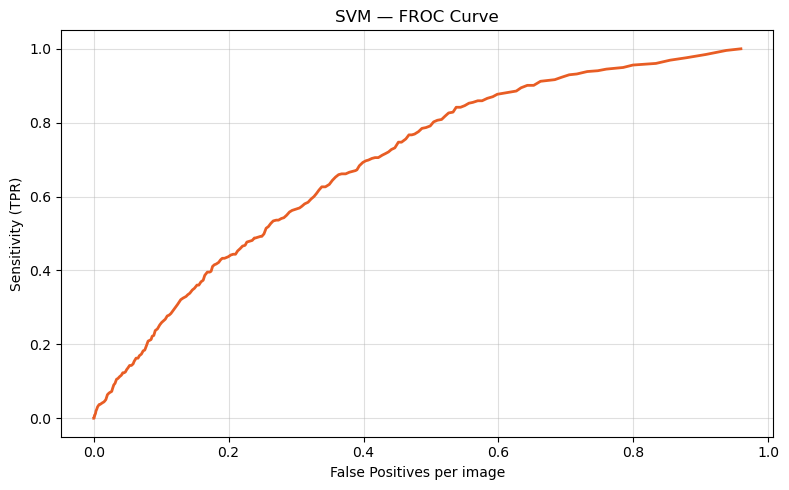

In [48]:
plot_froc('SVM', y_test, y_prob_svm, n_images=len(y_test))

In [49]:
with open('svm_model_random.pkl', 'wb') as file: #--> If you see errors here, try changing the directory to /ML/Models
    pickle.dump(best_svm, file)